# Parameter Grid Search

Systematically test Suite2p/Cellpose parameter combinations to find optimal settings.

**Key Features:**
- When searching only detection parameters, registration runs once and is reused
- Automatic quality metrics collection (SNR, skewness, shot noise)
- Built-in comparison visualizations

In [1]:
from pathlib import Path
import lbm_suite2p_python as lsp

# paths
data_dir = Path(r"D:/demo/raw")
save_path = Path(r"D:/demo/grid_search")

## Define Parameters

**Detection parameters** (fast - registration runs once):
- `threshold_scaling`, `diameter`, `spatial_hp_cp`, `anatomical_only`, `sparse_mode`

**Registration parameters** (slow - each combination re-registers):
- `nonrigid`, `block_size`, `maxregshift`, `smooth_sigma`

In [2]:
# parameters to search
grid_params = {
    "spatial_hp_cp": [0, 0.5, 3, 10],
}

# fixed parameters
ops = {
    "anatomical_only": 4,
    "diameter": 4,
}

## Run Grid Search

In [ ]:
lsp.grid_search(
    input_data=data_dir,
    save_path=save_path,
    grid_params=grid_params,
    ops=ops,
    planes=7,  # 1-indexed
    force_detect=True,
)

## Collect and Analyze Results

In [4]:
# collect metrics from all combinations
df = lsp.collect_grid_results(save_path, grid_params)
display(df[["combo", "n_accepted", "snr_median", "skew_median", "noise_median"] + list(grid_params.keys())])

# save to CSV
lsp.save_grid_results(df, save_path)

,combo,n_accepted,snr_median,skew_median,noise_median,spatial_hp_cp
1,spa0.50,12,2.080401,1.844024,0.039482,0.5
0,spa0,87,1.776383,1.572176,0.042776,0.0
3,spa3,92,1.710438,1.553694,0.041446,3.0
2,spa10,98,1.660820,1.548533,0.041515,10.0


Saved: D:\demo\grid_search\grid_search_results.csv


WindowsPath('D:/demo/grid_search/grid_search_results.csv')

## Best Parameters

In [5]:
lsp.print_best_parameters(df, grid_params)

Best Parameters by Different Criteria:

SNR: spa0.50
  Cells: 12
  SNR: 2.080
  Skewness: 1.844
  Shot Noise: 0.0395
  spatial_hp_cp: 0.5

SKEW: spa0.50
  Cells: 12
  SNR: 2.080
  Skewness: 1.844
  Shot Noise: 0.0395
  spatial_hp_cp: 0.5

NOISE: spa0.50
  Cells: 12
  SNR: 2.080
  Skewness: 1.844
  Shot Noise: 0.0395
  spatial_hp_cp: 0.5

COUNT: spa10
  Cells: 98
  SNR: 1.661
  Skewness: 1.549
  Shot Noise: 0.0415
  spatial_hp_cp: 10.0


## Visualize Quality Metrics

Saved: D:\demo\grid_search\quality_metrics.png


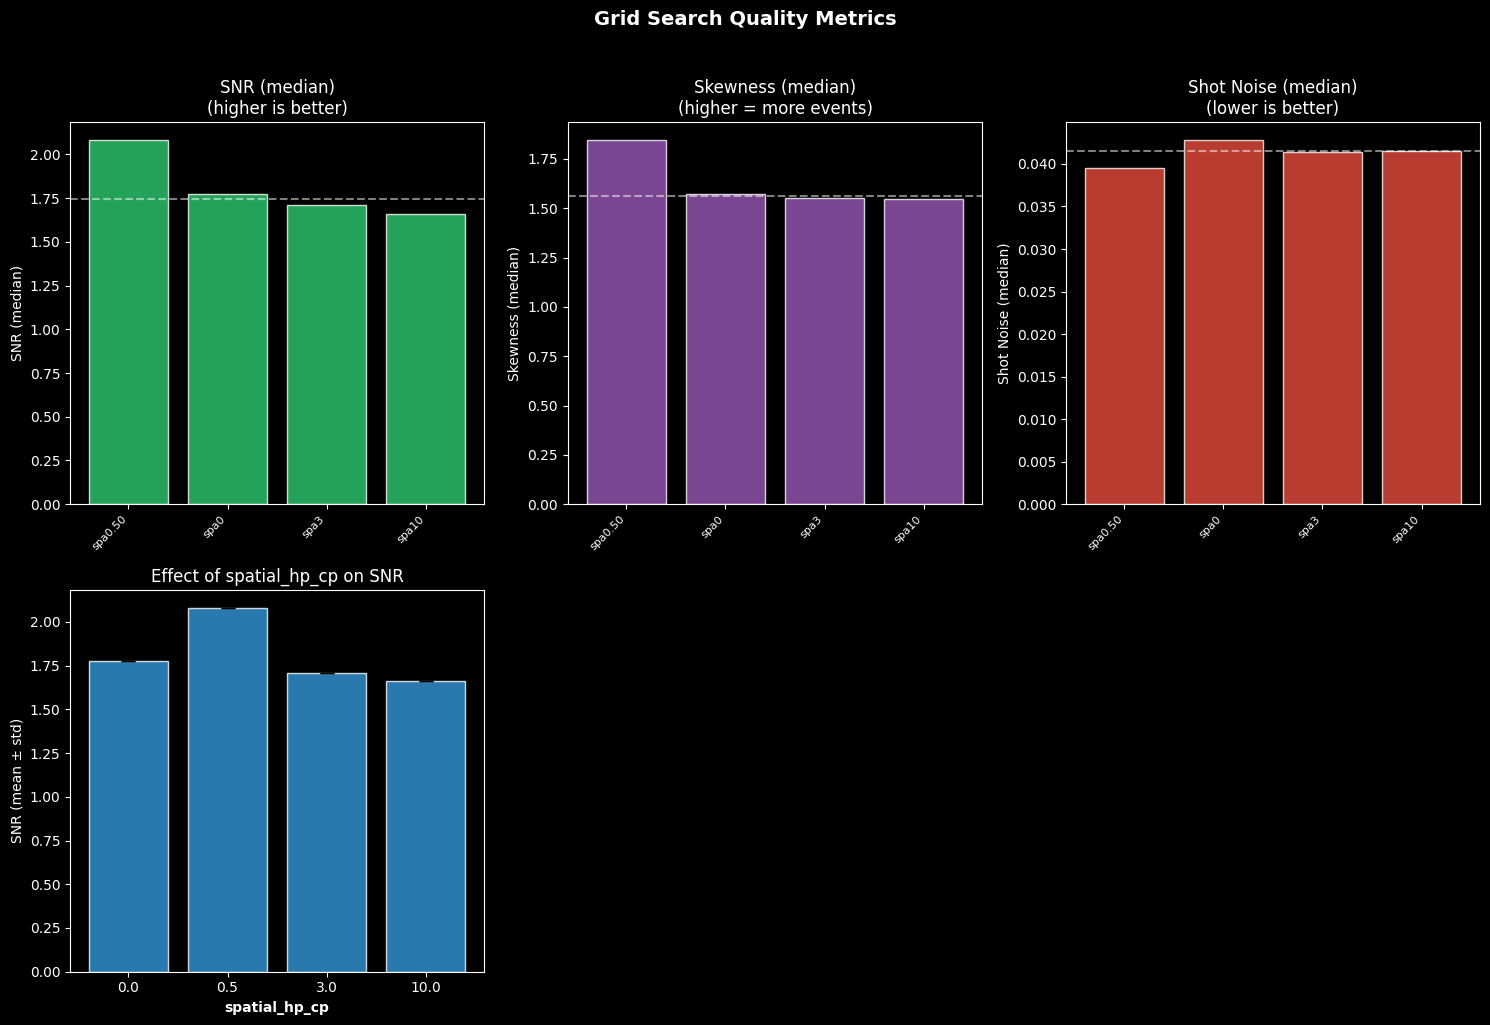

In [6]:
lsp.plot_grid_metrics(df, grid_params, save_path=save_path / "quality_metrics.png")

## Distribution Comparison

Saved: D:\demo\grid_search\distributions.png


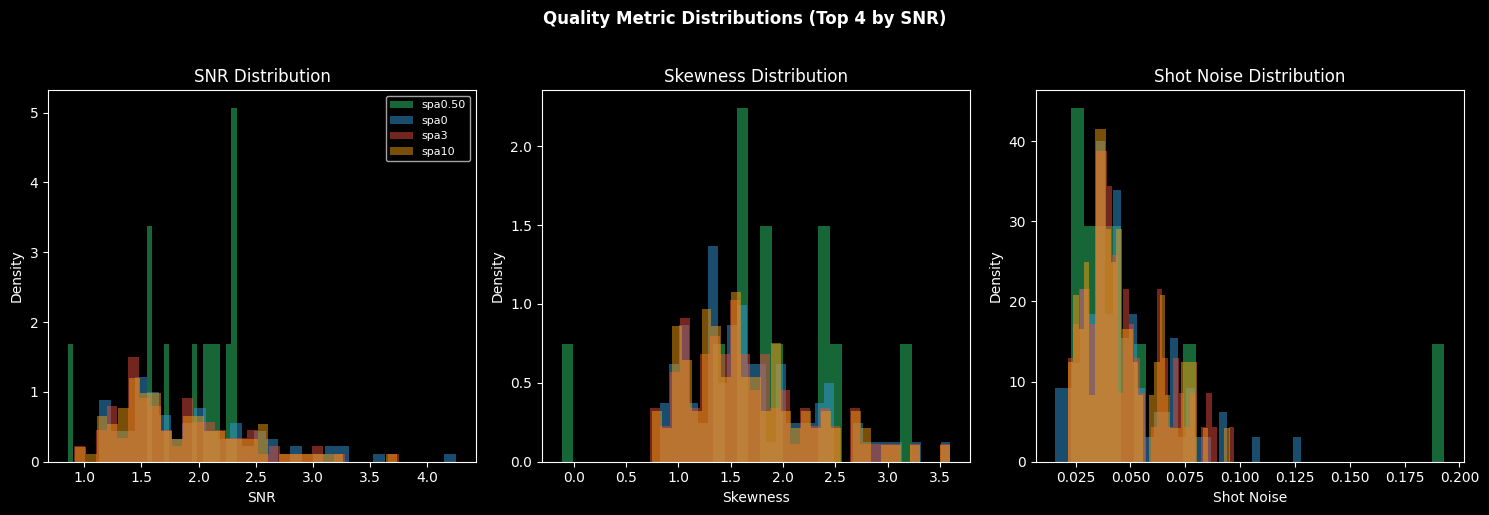

In [7]:
lsp.plot_grid_distributions(df, results_dir=save_path, n_top=4, save_path=save_path / "distributions.png")

## Compare Detection Masks

Saved: D:\demo\grid_search\masks.png


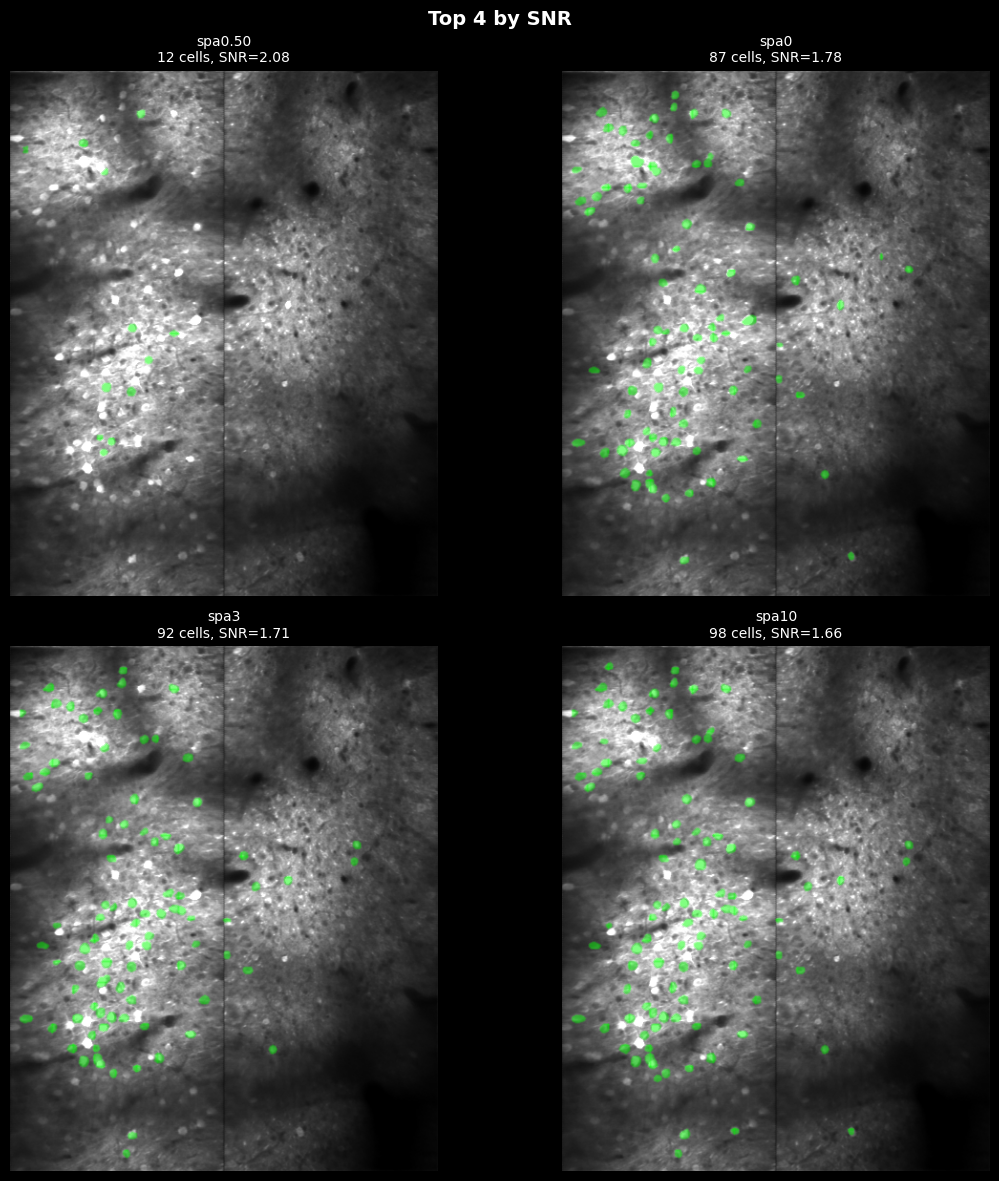

In [8]:
lsp.plot_grid_masks(df, results_dir=save_path, n_top=4, save_path=save_path / "masks.png")

## Output Structure

```
grid_search/
├── _base/                    # shared registration (detection-only search)
│   ├── data_raw.bin
│   ├── data.bin
│   └── ops.npy
├── grid_search_results.csv   # all metrics
├── quality_metrics.png
├── distributions.png
├── masks.png
├── spa0/
│   ├── ops.npy, stat.npy, F.npy, ...
├── spa0.50/
└── ...
```

## Using Best Parameters

```python
best = lsp.get_best_parameters(df)
best_ops = {"spatial_hp_cp": best["best_snr"]["spatial_hp_cp"]}

lsp.pipeline(
    input_data="D:/data/full_volume",
    save_path="D:/results/full_run",
    ops=best_ops,
)
```

In [9]:
help(lsp.pipeline)

Help on function pipeline in module lbm_suite2p_python.run_lsp:

pipeline(input_data, save_path: str | pathlib.Path = None, ops: dict = None, planes: list | int = None, roi: int = None, keep_reg: bool = True, keep_raw: bool = False, force_reg: bool = False, force_detect: bool = False, dff_window_size: int = None, dff_percentile: int = 20, dff_smooth_window: int = None, cell_filters: list = None, save_json: bool = False, reader_kwargs: dict = None, writer_kwargs: dict = None, **kwargs) -> list[pathlib.Path]
    Unified Suite2p processing pipeline for any input type.

    Uses mbo_utilities.imread() to handle all supported input formats:
    - Raw ScanImage TIFFs (with phase correction and ROI stitching)
    - Processed TIFFs, Zarr, HDF5 files
    - Existing Suite2p binaries (.bin + ops.npy)
    - Directories containing supported files
    - Pre-loaded lazy arrays from mbo_utilities

    Parameters
    ----------
    input_data : str, Path, list, or lazy array
        Input data source. 